In [1]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import Markdown
from IPython.display import Markdown, display
import pandas as pd

#sci-kitlear
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import joblib

#pyCaret
from pycaret.classification import setup, create_model, compare_models, plot_model, evaluate_model, predict_model, pull


In [2]:
%matplotlib inline

Orginal data set:
https://www.kaggle.com/code/emineyetm/telco-customer-churn/notebook

Author of dataset:
https://www.kaggle.com/emineyetm

In [3]:
pd.set_option('display.max_columns', None)

In [ ]:
clean_df = pd.read_csv('data/telco_churn_clean.csv')

In [5]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaperlessBilling  7043 non-null   object 
 15  PaymentMethod     7043 non-null   object 
 16  MonthlyCharges    7043 non-null   float64


## 1 pyCaret

### 1.1 Setup

In [6]:
setup(
    data=clean_df,
    target='Churn',
    session_id=123,
)

,Description,Value
0,Session id,123
1,Target,Churn
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(7043, 18)"
5,Transformed data shape,"(7043, 39)"
6,Transformed train set shape,"(4930, 39)"
7,Transformed test set shape,"(2113, 39)"
8,Numeric features,3
9,Categorical features,14


### 1.2 model selection

In [7]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8024,0.8479,0.8024,0.7935,0.7953,0.4607,0.4655,0.3330
gbc,Gradient Boosting Classifier,0.8010,0.8489,0.8010,0.7920,0.7937,0.4563,0.4613,0.6050
lda,Linear Discriminant Analysis,0.8010,0.8397,0.8010,0.7949,0.7967,0.4693,0.4715,0.2170
lr,Logistic Regression,0.7992,0.8435,0.7992,0.7913,0.7931,0.4566,0.4606,0.8270
ridge,Ridge Classifier,0.7988,0.8397,0.7988,0.7887,0.7901,0.4445,0.4511,0.1780
lightgbm,Light Gradient Boosting Machine,0.7903,0.8320,0.7903,0.7818,0.7839,0.4331,0.4367,28.7280
rf,Random Forest Classifier,0.7844,0.8161,0.7844,0.7735,0.7756,0.4073,0.4131,0.5200
knn,K Neighbors Classifier,0.7718,0.7784,0.7718,0.7646,0.7670,0.3922,0.3942,0.1920
et,Extra Trees Classifier,0.7627,0.7809,0.7627,0.7504,0.7539,0.3514,0.3555,0.5720
svm,SVM - Linear Kernel,0.7554,0.8019,0.7554,0.7275,0.7279,0.3263,0.3404,0.2150


## Model Selection – Implications

#### 1. No clear winner

Since all models achieved similar performance, the choice of algorithm has a limited impact on overall predictive accuracy.

#### 2. Preference for simpler models

Given the negligible performance differences, a simpler model such as Logistic Regression is preferred due to its interpretability, stability, and lower computational cost.

#### 3. The importance of data > model

The results suggest that model performance is primarily constrained by the dataset, indicating that further improvements are more likely to come from feature engineering rather than more complex algorithms.

#### 4. Business consequence

The ability to interpret model outputs is crucial for business decision-making, making simpler models more practical despite similar predictive performance.

# 3 Sci-kitlearn operatoion

### 3.1. X/Y division

In [8]:
X = clean_df.drop('Churn', axis=1)
y = clean_df['Churn']

### 3.2. Target encoding

In [9]:
y = y.map({'Yes': 1, 'No': 0})

### 3.3. feature encoding
✔️ binary (Yes/No) 'Partner', 'Dependents', 'PaperlessBilling'

In [10]:
binary_cols = ['Partner', 'Dependents', 'PaperlessBilling']

for col in binary_cols:
    X[col] = X[col].map({'Yes': 1, 'No': 0})

✔️ One-Hot else remains

In [11]:
X = pd.get_dummies(X, drop_first=True)

### 3.4. Train / test split

In [12]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3.5. First model (baseline)

In [13]:


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

### 3.6. Predyction

In [14]:
y_pred = model.predict(X_test)

### 3.7. Assessment

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.81      1409



### The Logistic Regression model achieves an overall accuracy of 82%, but its ability to detect churn is limited, with a recall of only 58% for the churn class. This indicates that a significant portion of customers who are likely to leave are not correctly identified, which may limit the model's usefulness in a business context.

## 4. Improving actions:
1. class_weight (class_weight='balanced')

2. threshold tuning 0.5 → np. 0.3

1 - Probabilities

In [16]:
y_proba = model.predict_proba(X_test)[:, 1]

2 - Seting Threshold

In [17]:
# threshold = 0.3

# y_pred_custom = (y_proba >= threshold).astype(int)

In [18]:
# print(classification_report(y_test, y_pred_custom))

In [19]:
for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred = (y_proba >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.81      1409


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1036
           1       0.61      0.68      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1036
           1       0.55      0.79      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82   

## ROC curve

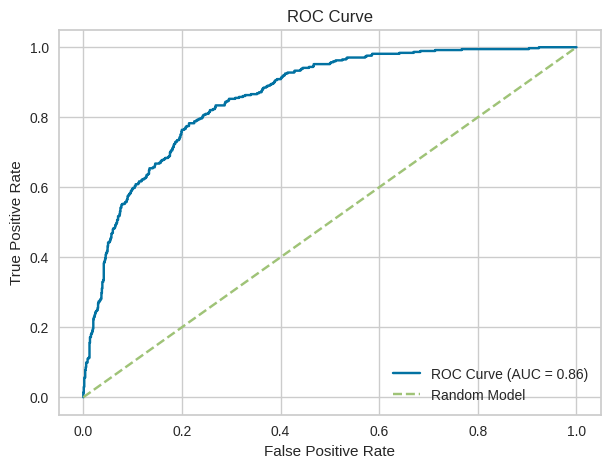

In [20]:
# calculations
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# plot
plt.figure(figsize=(7,5))

# ROC curve
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")

# diagonal line
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Model')

# descriptions
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

# legend
plt.legend(loc="lower right")

# siatka (ładniej wygląda)
plt.grid(True)

plt.show()

The ROC curve demonstrates that the model has strong discriminative ability, with an AUC of approximately 0.86, indicating good overall performance in distinguishing between churn and non-churn customers.

The curve represents the model's performance across all possible classification thresholds, highlighting the trade-off between true positive rate (recall) and false positive rate.

By adjusting the classification threshold, the model can be tuned to prioritize either higher recall (capturing more churn cases) or higher precision (reducing false positives).

In this analysis, thresholds in the range of 0.3–0.4 provide a reasonable balance, significantly improving churn detection while maintaining acceptable precision.

## 4. Final best model

#### Treshold = 0.4

#### - Why?

A threshold of 0.4 was selected as it provides a balanced trade-off between recall and precision. At this level, the model significantly improves the detection of churn cases compared to the default threshold (0.5), while keeping the number of false positives at an acceptable level. This balance is important from a business perspective, where identifying at-risk customers is valuable, but excessive false alerts may lead to inefficient resource allocation.

In [21]:
threshold = 0.4

y_pred_custom_best = (y_proba >= threshold).astype(int)

In [22]:
print(classification_report(y_test, y_pred_custom_best))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1036
           1       0.61      0.68      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409



### Top Features Influencing Churn (Logistic Regression)

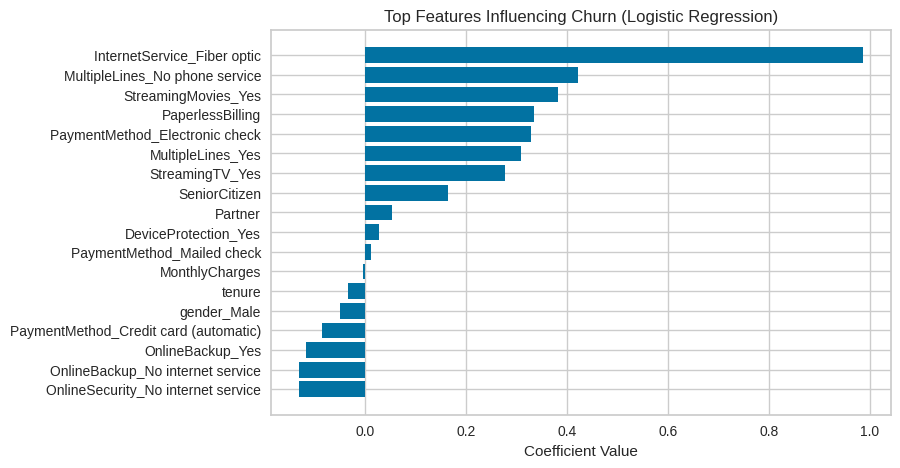

In [23]:
# pobierz współczynniki
coefficients = model.coef_[0]

# przypisz do kolumn
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": coefficients
})

# sortuj
feature_importance = feature_importance.sort_values(by="importance", ascending=False)

# top 10
top = feature_importance.head(18)

# wykres
plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.title("Top Features Influencing Churn (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()

## 5. L1 model

### L1 regularization was applied to simplify the model by reducing the number of features, without impacting performance. The final model combines L1 regularization with a threshold of 0.4, resulting in improved churn detection and a more interpretable model.

In [25]:
model_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    C=0.5  # we can change affter
)

model_l1.fit(X_train, y_train)

LogisticRegression(C=0.5, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l1',
                   random_state=None, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)

### how many features does the model use

In [26]:
coef = model_l1.coef_[0]

display(Markdown(f"### Number of features: {len(coef)}"))
display(Markdown(f"### Non-zero features (in use): {np.sum(coef != 0)}"))

### Number of features: 28

### Non-zero features (in use): 27

### Feature Importance (L1 Logistic Regression)

In [27]:
feature_importance_l1 = pd.DataFrame({
    "feature": X.columns,
    "coef": coef
})

# only non-zero
selected = feature_importance_l1[feature_importance_l1["coef"] != 0]

# sort
selected = selected.sort_values(by="coef", ascending=False)

selected

,feature,coef
9,InternetService_Fiber optic,1.235715
22,StreamingMovies_Yes,0.479389
20,StreamingTV_Yes,0.373055
8,MultipleLines_Yes,0.346969
26,PaymentMethod_Electronic check,0.325098
4,PaperlessBilling,0.321599
7,MultipleLines_No phone service,0.178042
0,SeniorCitizen,0.159141
16,DeviceProtection_Yes,0.065565
1,Partner,0.035232


### Plot for Feature Importance (L1 Logistic Regression)

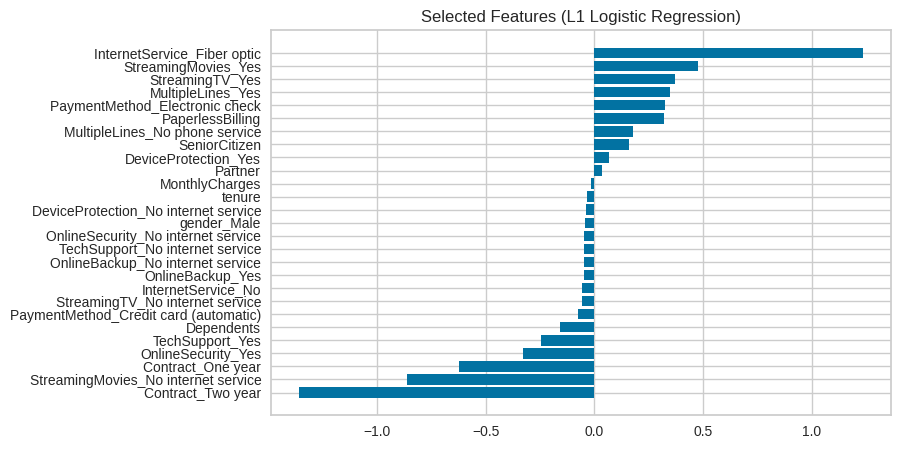

In [28]:
plt.figure(figsize=(8,5))
plt.barh(selected["feature"], selected["coef"])
plt.gca().invert_yaxis()
plt.title("Selected Features (L1 Logistic Regression)")
plt.show()

### Metric for Feature Importance (L1 Logistic Regression)

In [29]:
y_pred_l1 = model_l1.predict(X_test)
print(classification_report(y_test, y_pred_l1))


              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



The L1-regularized model achieves similar performance to the original Logistic Regression model, indicating that feature reduction did not negatively impact predictive quality. This suggests that many features were redundant and could be safely removed. However, the model still shows limited recall for churn (58%), meaning a significant portion of at-risk customers remains undetected.

# 6. Treshold 0.4 +L1

In [30]:
y_proba_l1 = model_l1.predict_proba(X_test)[:, 1]

In [31]:
threshold = 0.4

y_pred_l1_custom = (y_proba_l1 >= threshold).astype(int)

### Metric for Feature Importance (L1 Logistic Regression + Threshold 0.4)

In [32]:
print(classification_report(y_test, y_pred_l1_custom))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1036
           1       0.61      0.68      0.64       373

    accuracy                           0.80      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409



The ROC AUC score for the L1-regularized Logistic Regression model is approximately 0.85, indicating good discriminative ability. This means the model is effective at distinguishing between customers who churn and those who remain. Importantly, this performance was achieved despite reducing the number of features, suggesting that the removed variables were not essential for prediction.

In [33]:
auc_l1 = roc_auc_score(y_test, y_proba_l1)
print(f"AUC (L1 model): {auc_l1:.3f}")

AUC (L1 model): 0.861


## Confusion matrix

In [34]:
print(confusion_matrix(y_test, y_pred_l1_custom))

[[873 163]
 [121 252]]


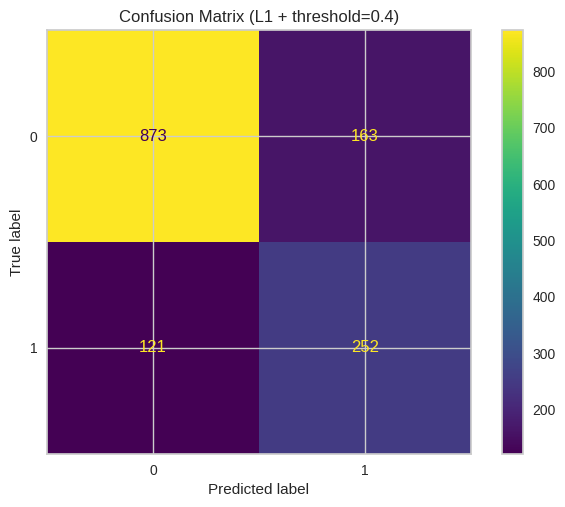

In [35]:
cm = confusion_matrix(y_test, y_pred_l1_custom)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (L1 + threshold=0.4)")
plt.show()

### The model correctly identifies 252 churn cases while missing 121, achieving a recall of ~68%. It also produces 163 false positives, indicating a moderate trade-off between detection rate and operational cost.

## ROC curve with Threshold 0.4

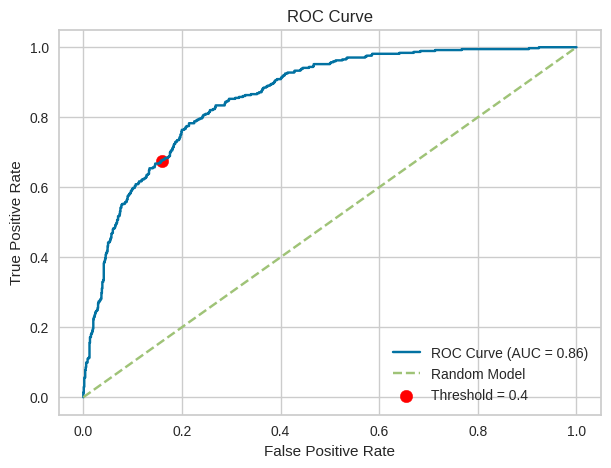

In [36]:
# obliczenia
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# znajdź indeks dla threshold ~0.4
idx = np.argmin(np.abs(thresholds - 0.4))

# wykres
plt.figure(figsize=(7,5))

# krzywa ROC
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")

# linia losowa
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Model')

# 🔴 punkt dla threshold = 0.4
plt.scatter(fpr[idx], tpr[idx], color='red', s=80, label='Threshold = 0.4')

# opisy
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

## By adjusting the classification threshold to 0.4 and applying L1 regularization, the model improved its ability to detect churn cases, increasing recall from 58% to 68%. Although this resulted in a slight decrease in precision and overall accuracy, the model is now more effective in identifying at-risk customers, which is more valuable from a business perspective.

# 🔥 6. Cross-Validation

In [37]:
model_cv = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    C=0.5
)

scores = cross_val_score(model_cv, X, y, cv=10, scoring='roc_auc')

print("AUC scores:", scores)
print("Mean AUC:", scores.mean())

AUC scores: [0.84533273 0.86690893 0.84756261 0.86742849 0.8474436  0.81958336
 0.83809307 0.8311112  0.83377983 0.83853784]
Mean AUC: 0.8435781663359941


#### Using 10-fold cross-validation, the model achieves AUC scores ranging from approximately 0.82 to 0.87, with a mean of 0.84. The relatively small variation across folds confirms that the model is stable and generalizes well, even under more rigorous validation.

# 7. Model Serialization

In [38]:
final_model_bundle = {
    "model": model_l1,
    "threshold": 0.4,
    "features": X.columns.tolist()
}

joblib.dump(final_model_bundle, "clasyfication_model/churn_model_final.pkl")

['clasyfication_model/churn_model_final.pkl']

## The final model is a Logistic Regression with L1 regularization, combined with a classification threshold of 0.4. This configuration provides a balance between model simplicity, interpretability, and improved churn detection performance.

In [60]:
# Markdown("# PLAY")

In [61]:
# df_in = pd.read_csv('data/telco_churn_clean.csv')
# df_in

In [ ]:
# bundle = joblib.load("clasyfication_model/churn_model_final.pkl")

# model = bundle["model"]
# threshold = bundle["threshold"]
# features = bundle["features"]

In [ ]:
# import pandas as pd

# new_customer = pd.DataFrame([{
#     "gender": "Male",
#     "SeniorCitizen": 0,
#     "Partner": "Yes",
#     "Dependents": "No",
#     "tenure": 5,
#     "MultipleLines": "No",
#     "InternetService": "DSL",
#     "OnlineSecurity": "No",
#     "OnlineBackup": "No",
#     "DeviceProtection": "Yrs",
#     "TechSupport": "Yes",
#     "StreamingTV": "Yes",
#     "StreamingMovies": "No",
#     "Contract": "Two year",
#     "PaperlessBilling": "Yes",
#     "PaymentMethod": "Electronic check",
#     "MonthlyCharges": 100.0
# }])

In [ ]:
# # mapowanie
# binary_cols = ['Partner', 'Dependents', 'PaperlessBilling']
# for col in binary_cols:
#     new_customer[col] = new_customer[col].map({'Yes': 1, 'No': 0})

# # dummies
# X_new = pd.get_dummies(new_customer)

# # 🔥 KLUCZ
# X_new = X_new.reindex(columns=features, fill_value=0)

In [ ]:
# proba = model.predict_proba(X_new)[0][1]
# pred = (proba >= threshold).astype(int)

# print("Probability:", proba)
# print("Prediction:", pred)

Probability: 0.09611286458719061
Prediction: 0


---